# BDT Evaluation (XGBoost)

<div style="text-align: justify">

The following notebook evaluates the gradient-boosted decision tree classifier trained in <b>05a_bdt_training</b>. It consumes the persisted model and test-set predictions produced by the training pipeline and generates a comprehensive suite of quality metrics and visualisations.

Two split strategies are supported, mirroring those of the training notebook:

* <b>train_test</b> — evaluation on the held-out 20 % test set.
* <b>k_fold</b> — evaluation on the concatenated out-of-fold (OOF) predictions covering the full dataset.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| MLflow | `mlflow` | Resume training run and log evaluation metrics |
| Load | `bdt.load_model`, `io.load_dataframe` | Load persisted model(s) and predictions parquet |
| Labels | — | Derive ordered class names and display labels from config |
| Feature Importance | `evaluate.plot_feature_importance` | XGBoost built-in gain-based importance |
| SHAP | `evaluate.compute_shap_values`, `evaluate.plot_shap_importance` | SHAP multiclass feature attribution |
| Summary Metrics | `evaluate.compute_summary_metrics` | Accuracy, F1, per-class AUC |
| Classification Report | `evaluate.plot_classification_report` | Per-class precision, recall, F1-score |
| Confusion Matrix | `evaluate.plot_confusion_matrix` | Row-normalised confusion matrix |
| ROC Curves | `evaluate.plot_roc_curves` | Per-class one-vs-rest ROC curves |
| PR Curves | `evaluate.plot_pr_curves` | Per-class precision-recall curves |
| Score Distributions | `evaluate.plot_score_distributions` | Classifier output distributions per class |
| Save | `visualization.plots.save_figure` | Persist all plots to disk and log to MLflow |

The same pipeline is available as a CLI via `python run.py stage=evaluate` or `make evaluate`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)

Data Visualization:
* [Atlas MPL Style](https://atlas-mpl.readthedocs.io/en/latest/styles.html)
* [Matplotlib](https://matplotlib.org/)
* [Seaborn](https://seaborn.pydata.org/)

Machine Learning:
* [XGBoost](https://xgboost.readthedocs.io/en/stable/)
* [scikit-learn](https://scikit-learn.org/stable/)
* [SHAP](https://shap.readthedocs.io/en/latest/)

Experiment Tracking:
* [MLflow](https://mlflow.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration. The split strategy and all path parameters must match those used during training.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

## MLflow

Resuming the most recent training run for this experiment so that evaluation metrics and artifacts are logged to the same run.

In [5]:
import logging

import mlflow

logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("alembic").setLevel(logging.WARNING)

tracking_uri = f"file://{path}/mlruns"
mlflow.set_tracking_uri(tracking_uri)

experiment_name = cfg.get("experiment_name", "tau-supersymmetry-search-baseline")
client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)
experiment = client.get_experiment_by_name(experiment_name)

latest_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1,
)
run_id = latest_runs[0].info.run_id
run = mlflow.start_run(run_id=run_id)

print(f"Resumed MLflow run ID: {run_id}")

Resumed MLflow run ID: c04c0d80bbe6472ba5be3b83e9281179


## Deserialization

Resolving input and output directories from config.

In [6]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "bdt_evaluation"

plots_dir.mkdir(parents=True, exist_ok=True)

Deriving ordered class names and display labels from `eventOrigin`.

In [7]:
from omegaconf import OmegaConf
from src.eda.utils import get_class_names, get_class_labels
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")

display_labels = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)
class_names = get_class_names(df_mc)
class_labels = get_class_labels(df_mc, display_labels=display_labels)
n_classes = len(class_names)

print(f"Classes ({n_classes}): {class_names}")
class_labels

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


['top quarks',
 '$W \\rightarrow \\tau\\nu$',
 '$Z \\rightarrow \\tau\\tau$',
 'diboson',
 'other',
 'signal']

Loading the trained model(s) from disk.

In [8]:
from src.models.bdt import load_model

split_strategy = cfg.pipeline.split_strategy

if split_strategy == "train_test":
    model = load_model(models_dir / "bdt.ubj")
    print(f"Loaded model — best iteration: {model.best_iteration}")

elif split_strategy == "k_fold":
    import re
    fold_paths = sorted(models_dir.glob("bdt_fold*.ubj"), key=lambda p: int(re.search(r"\d+", p.stem).group()))
    models = [load_model(p) for p in fold_paths]
    print(f"Loaded {len(models)} fold models")
    print(f"Best iterations: {[m.best_iteration for m in models]}")

Loaded model — best iteration: 999


Loading the test-set predictions produced by the training pipeline.

In [9]:
import numpy as np

predictions_df = load_dataframe(dataframes_dir / "bdt_predictions.parquet")

y_true = predictions_df["y_true"].to_numpy()
y_pred = predictions_df["y_pred"].to_numpy()
y_proba = predictions_df[[f"p_{name}" for name in class_names]].to_numpy()

print(f"Predictions loaded: {len(predictions_df):,} events")
predictions_df.head()

Predictions loaded: 1,965,434 events


,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,5,5,0.000773,0.000062,0.000064,0.000574,0.000808,0.997719
1,5,5,0.004015,0.001955,0.015528,0.015406,0.001977,0.961119
2,3,1,0.077373,0.439130,0.105537,0.365531,0.009417,0.003013
3,2,2,0.033574,0.242270,0.501120,0.202825,0.013308,0.006904
4,0,4,0.435631,0.011424,0.007481,0.039033,0.499422,0.007009


## Feature Importance

### Built-in Importance

XGBoost built-in gain-based feature importance, showing the top 20 features. For K-fold models, importances are averaged across all folds.

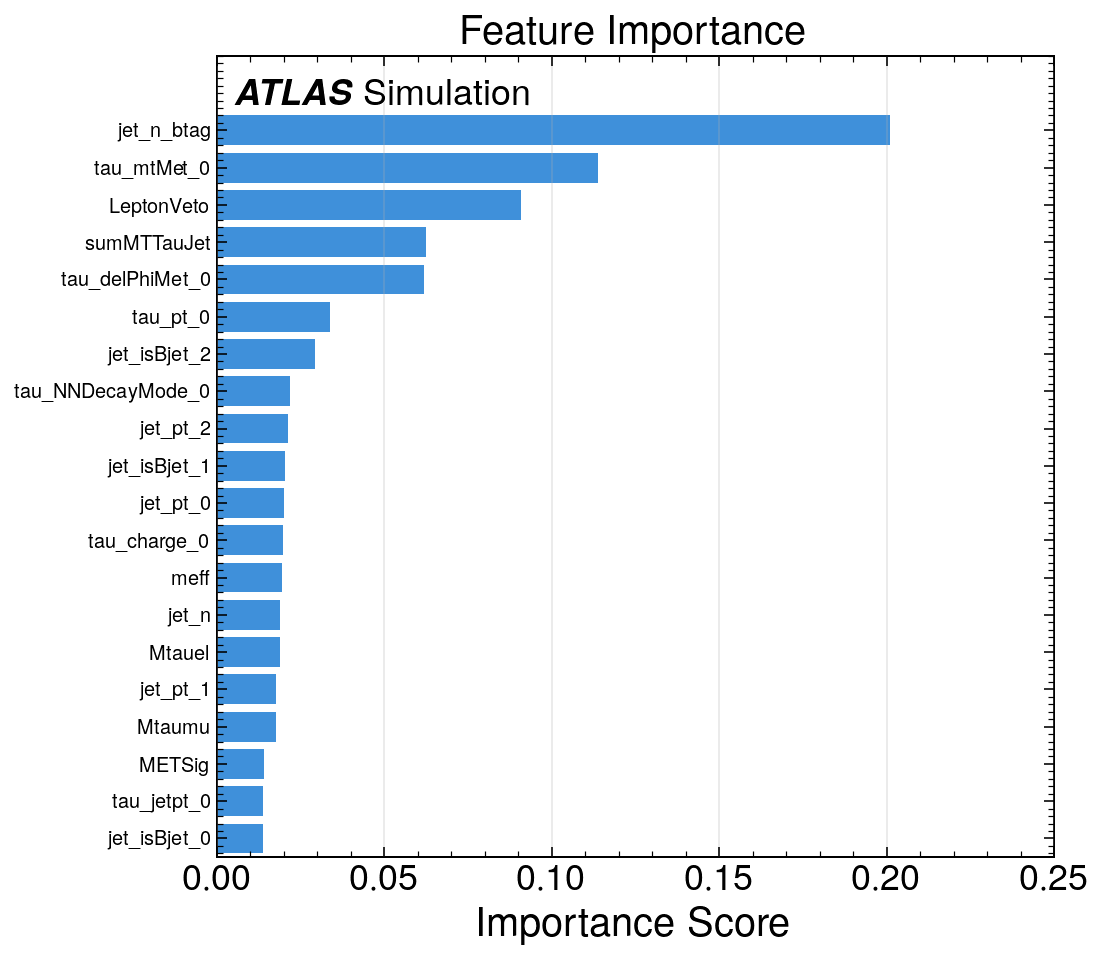

In [10]:
from src.models.evaluation import plot_feature_importance
from src.visualization.plots import save_figure

if split_strategy == "train_test":
    fi_model = model
elif split_strategy == "k_fold":
    import copy
    fi_model = copy.copy(models[0])
    fi_model.feature_importances_ = np.mean(
        [m.feature_importances_ for m in models], axis=0
    )

feature_names = list(predictions_df.columns.difference(["y_true", "y_pred"] + [f"p_{n}" for n in class_names]))

feature_names = fi_model.feature_names_in_.tolist()

fig = plot_feature_importance(fi_model, feature_names=feature_names, n_features=20)
fi_path = plots_dir / "feature_importance.png"
save_figure(fig, fi_path)
mlflow.log_artifact(str(fi_path))
fig.show()

### SHAP Values

Per-class SHAP feature attributions, showing the mean |SHAP value| per feature per output class for the top 20 features.

Computed on a random subsample (`n_samples = 2000`). For K-fold models, the first fold is used.

In [11]:
from src.models.splits import prepare_features_target

X, _, _ = prepare_features_target(df_mc)
print(f"Feature matrix for SHAP: {X.shape}")

Feature matrix for SHAP: (9827169, 53)


In [12]:
from src.models.evaluation import compute_shap_values, plot_shap_importance

shap_model = model if split_strategy == "train_test" else models[0]

shap_values, X_sample = compute_shap_values(shap_model, X, n_samples=2000, seed=cfg.seed)
print(f"SHAP values computed on {len(X_sample):,} events")

SHAP values computed on 2,000 events


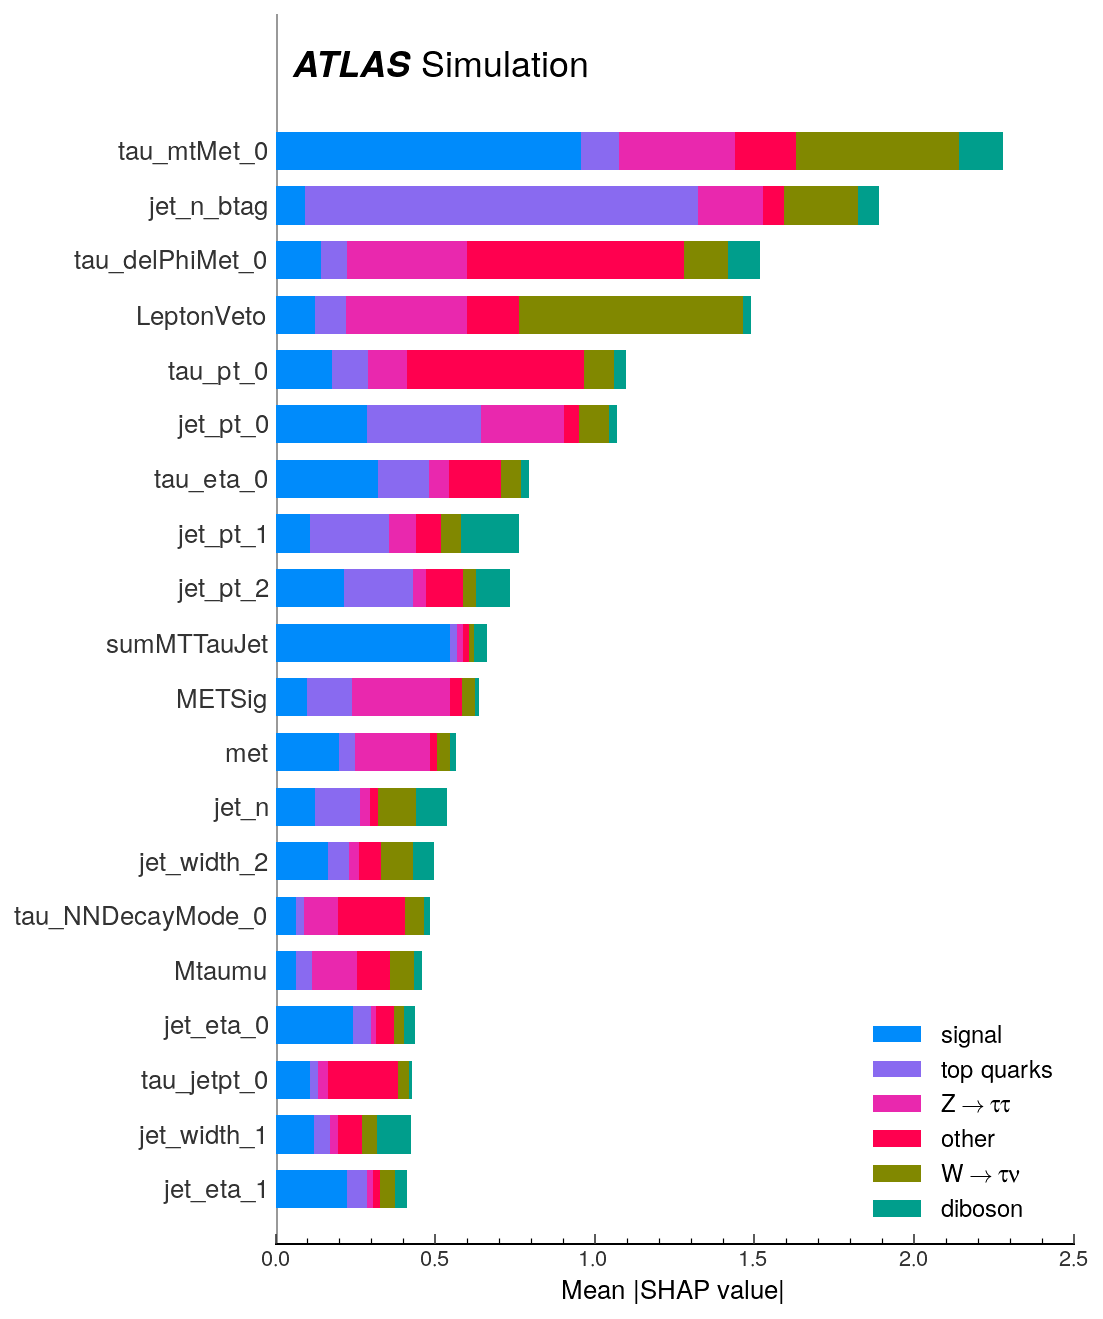

In [13]:
fig = plot_shap_importance(shap_values, X_sample, class_labels=class_labels, n_features=20)
shap_path = plots_dir / "shap_importance.png"
save_figure(fig, shap_path)
mlflow.log_artifact(str(shap_path))
fig.show()

## Classification Metrics

### Summary Metrics

Overall accuracy, macro and weighted F1-score, macro one-vs-rest AUC, and per-class AUC. All values are logged to the active MLflow run.

In [14]:
import pandas as pd
from src.models.evaluation import compute_summary_metrics

metrics = compute_summary_metrics(y_true, y_pred, y_proba, class_names)
mlflow.log_metrics(metrics)

summary = pd.Series(metrics).rename("value").to_frame()
summary["value"] = summary["value"].map("{:.4f}".format)
print(summary.to_string())

                value
accuracy       0.6346
f1_macro       0.6204
f1_weighted    0.6266
roc_auc_macro  0.9013
auc_topquarks  0.9452
auc_wtaunu     0.8778
auc_ztautau    0.9052
auc_diboson    0.7784
auc_other      0.9308
auc_signal     0.9705


### Classification Report

Per-class precision, recall, and F1-score heatmap with support counts.

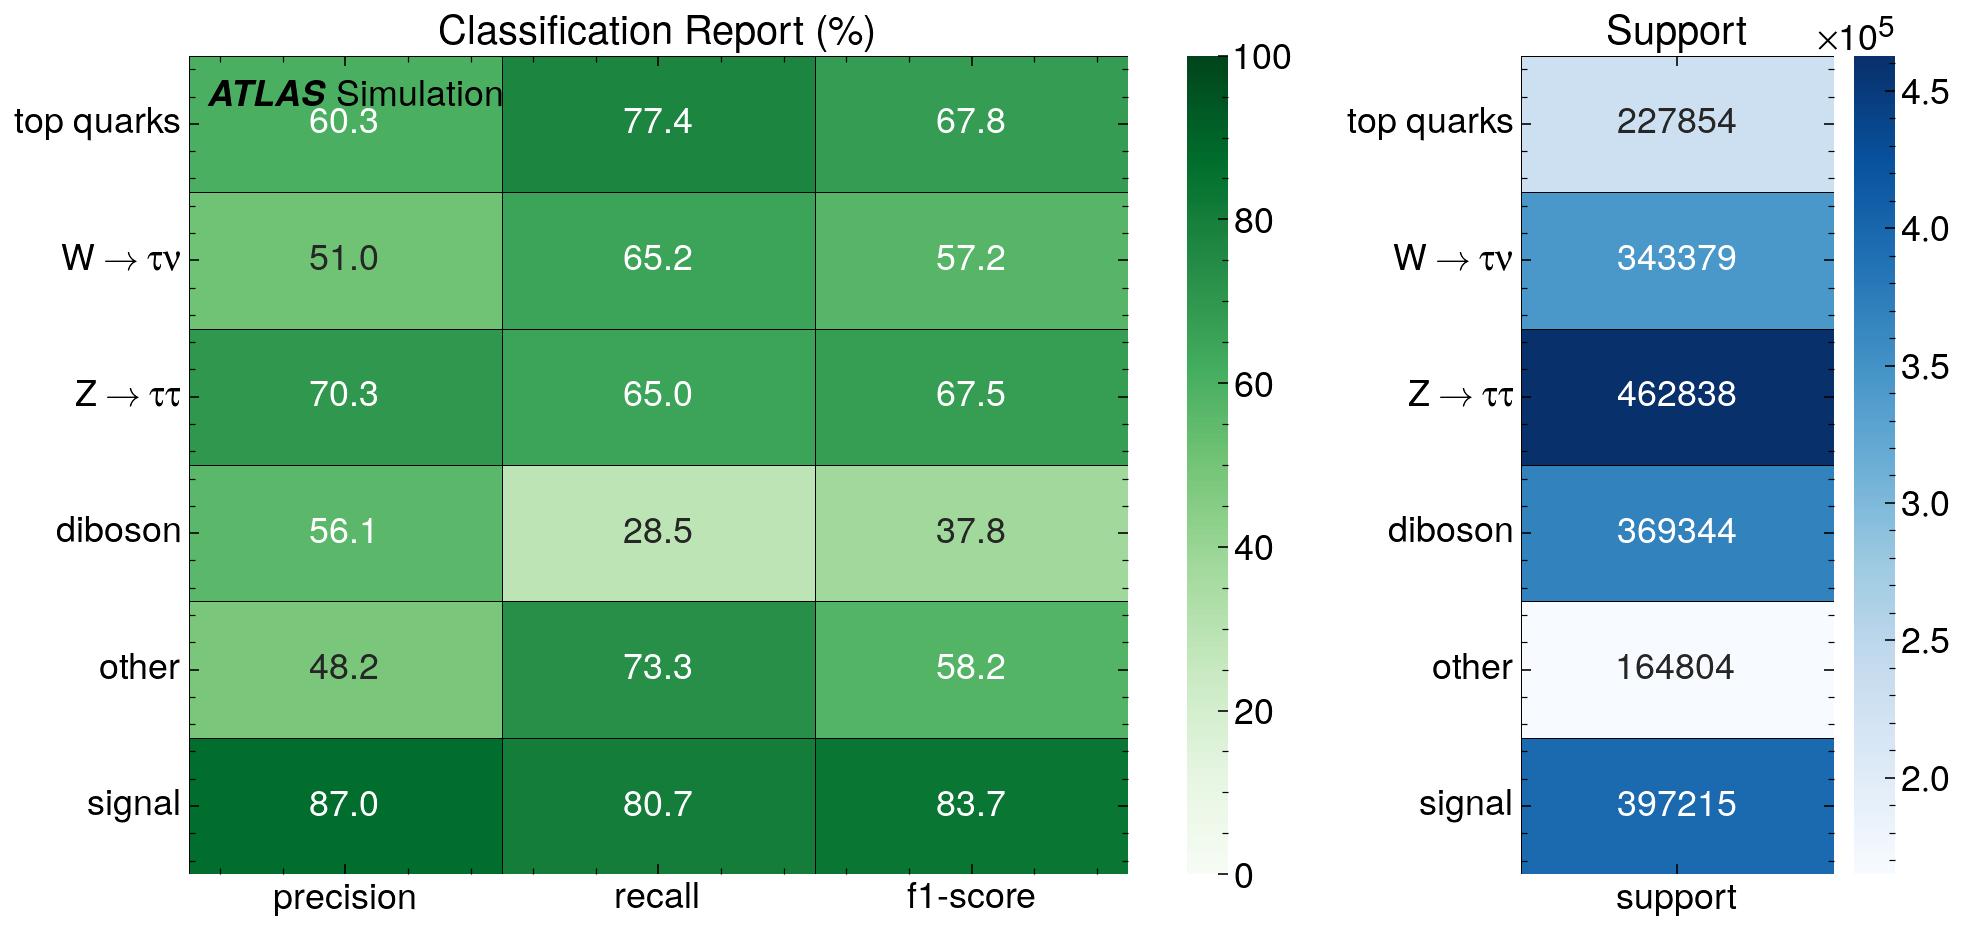

In [15]:
from src.models.evaluation import plot_classification_report

fig = plot_classification_report(y_true, y_pred, class_labels=class_labels)
cr_path = plots_dir / "classification_report.png"
save_figure(fig, cr_path)
mlflow.log_artifact(str(cr_path))
fig.show()

### Confusion Matrix

Row-normalised confusion matrix with absolute counts and per-class recall percentages.

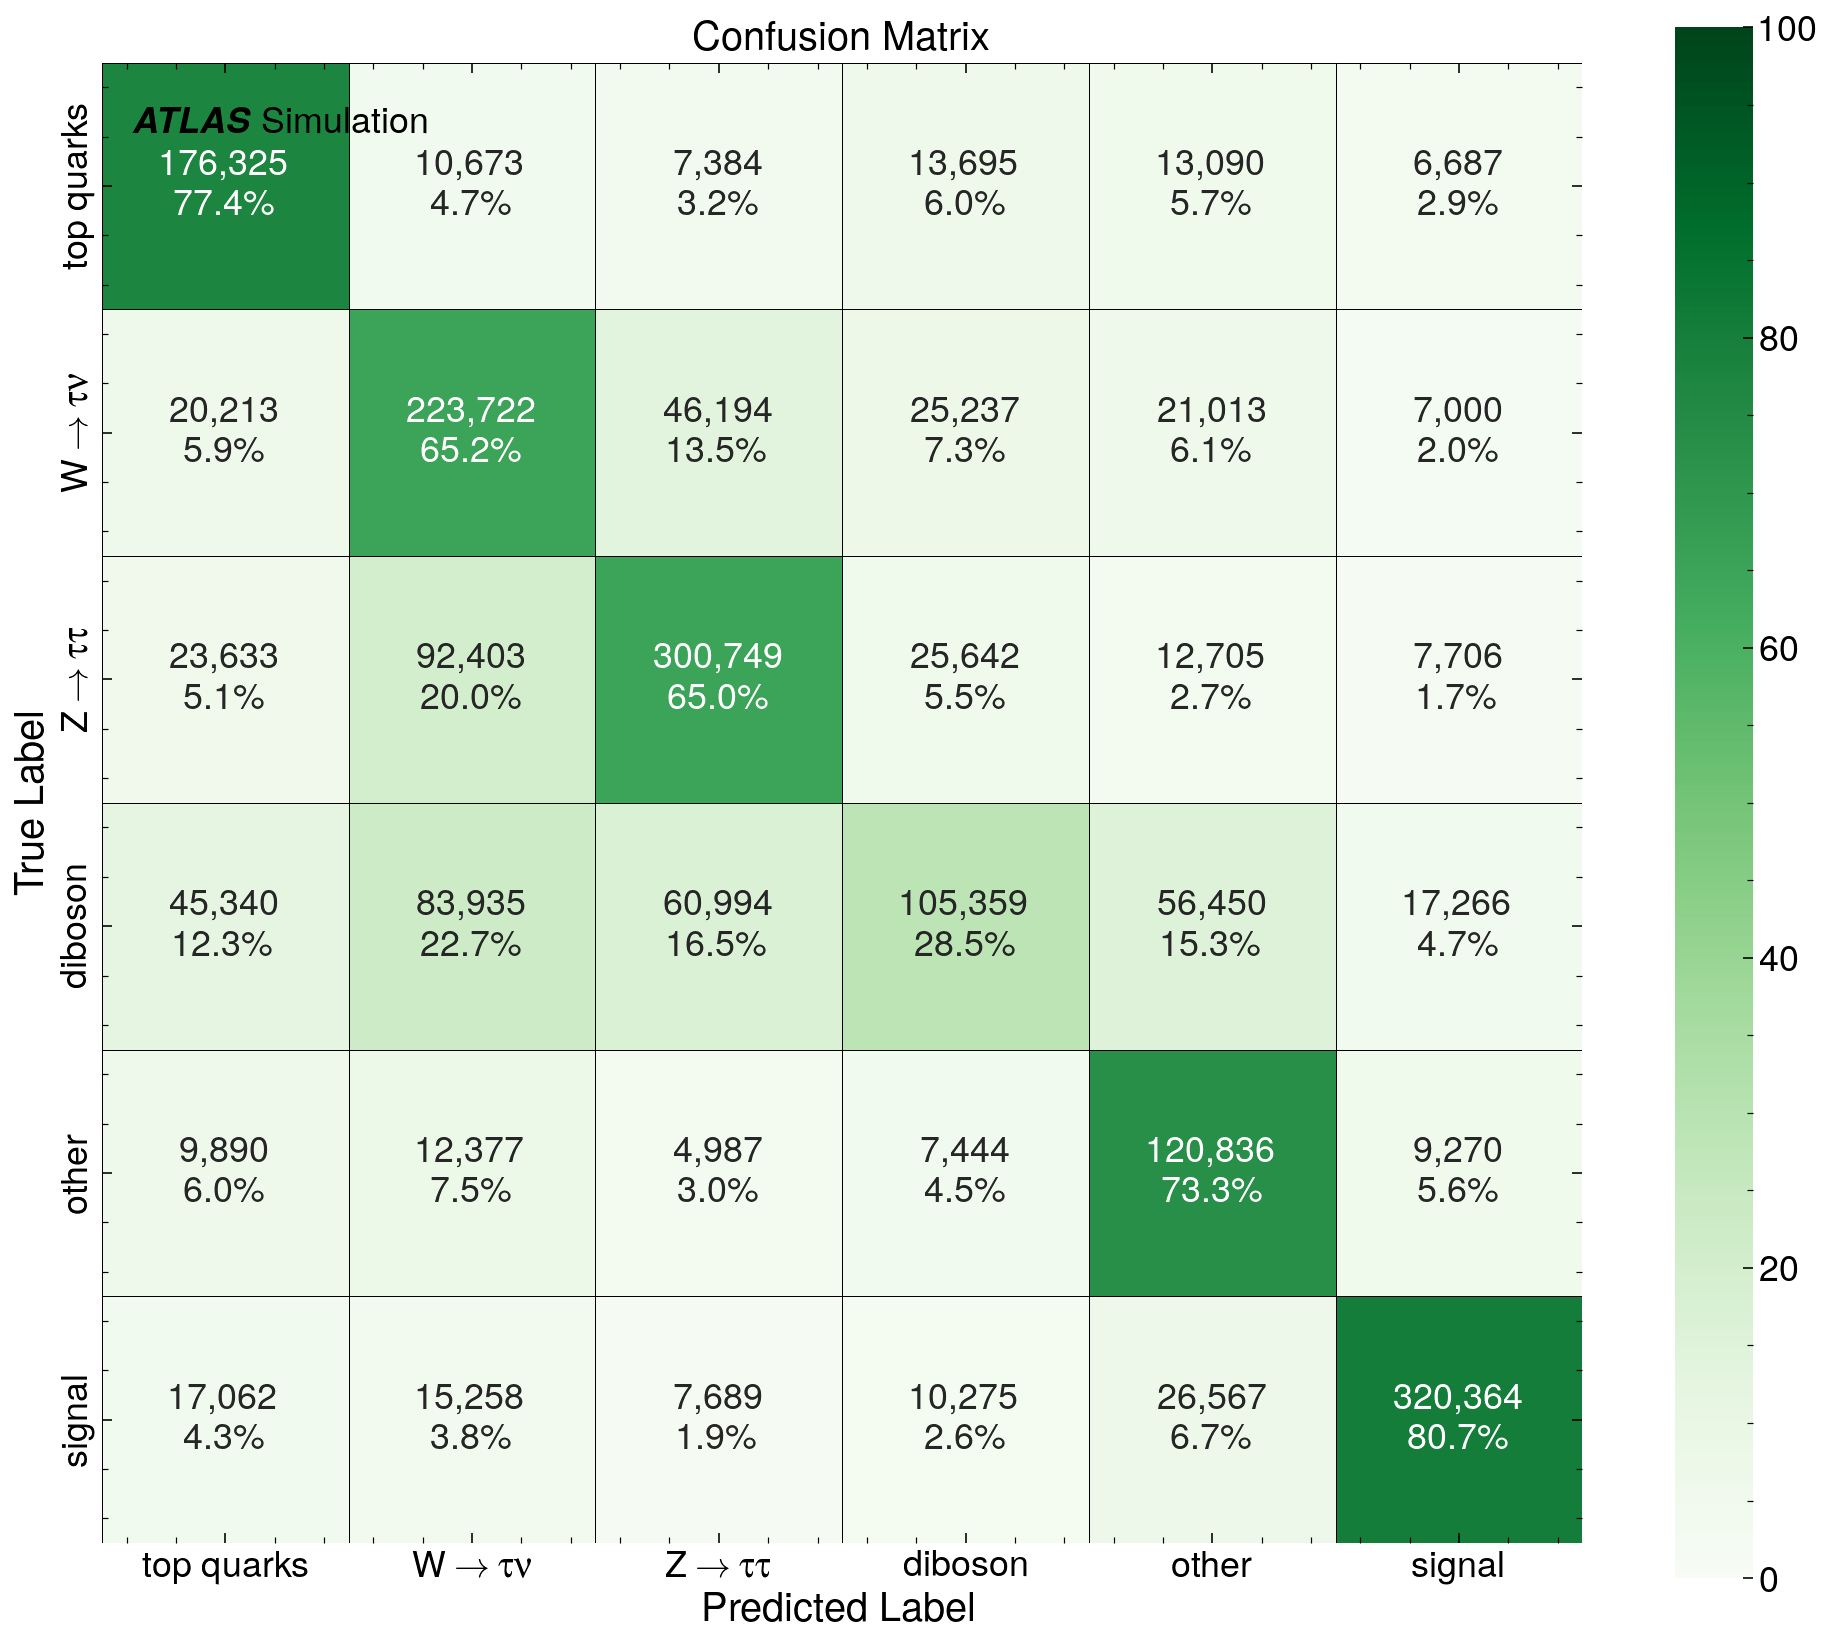

In [16]:
from src.models.evaluation import plot_confusion_matrix

fig = plot_confusion_matrix(y_true, y_pred, class_labels=class_labels)
cm_path = plots_dir / "confusion_matrix.png"
save_figure(fig, cm_path)
mlflow.log_artifact(str(cm_path))
fig.show()

## Curves

### ROC Curves

Per-class one-vs-rest ROC curves with AUC values.

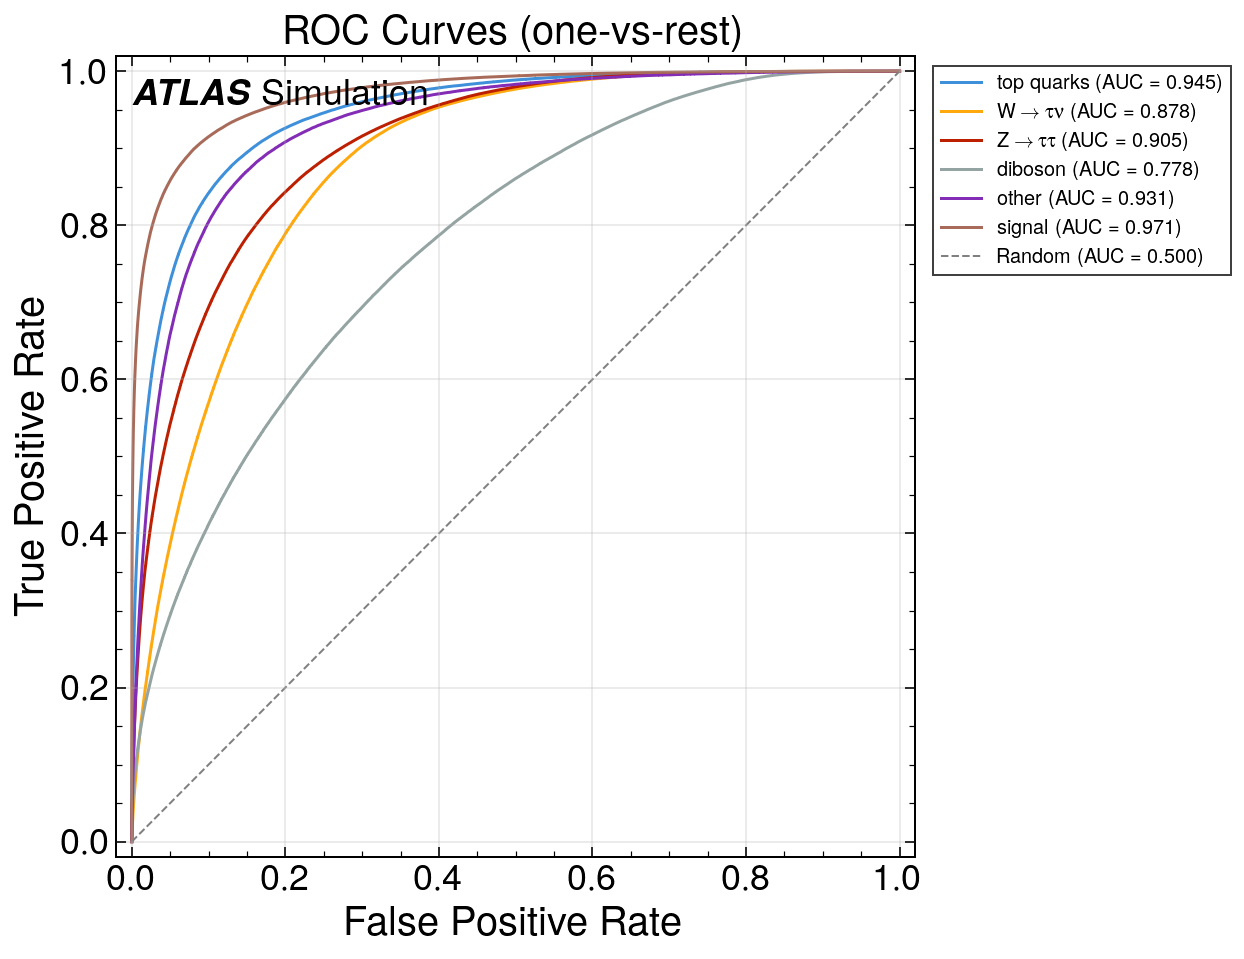

In [17]:
from src.models.evaluation import plot_roc_curves

fig = plot_roc_curves(y_true, y_proba, class_labels=class_labels)
roc_path = plots_dir / "roc_curves.png"
save_figure(fig, roc_path)
mlflow.log_artifact(str(roc_path))
fig.show()

### Precision-Recall Curves

Per-class one-vs-rest precision-recall curves with average precision (AP) values.

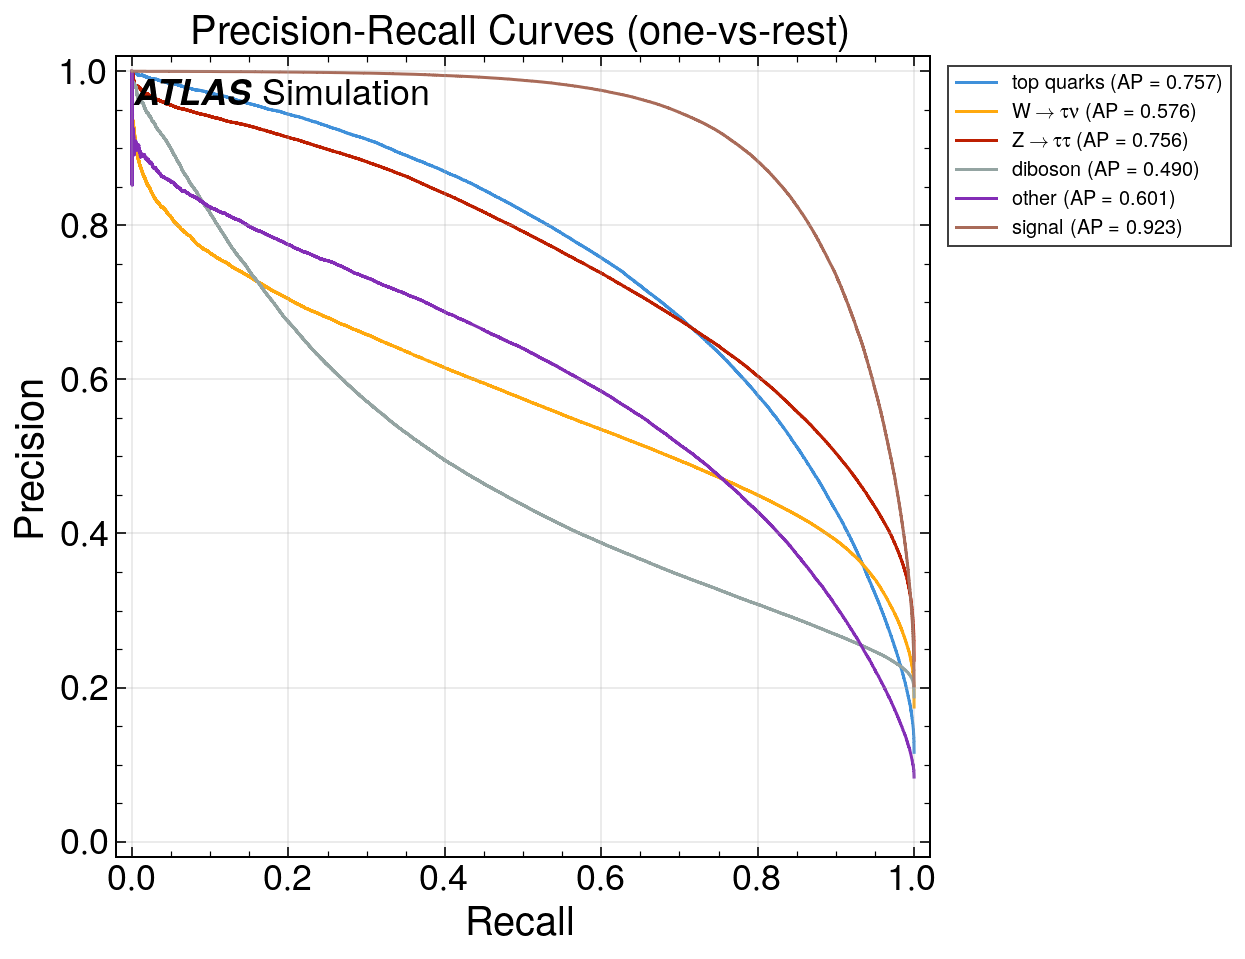

In [18]:
from src.models.evaluation import plot_pr_curves

fig = plot_pr_curves(y_true, y_proba, class_labels=class_labels)
pr_path = plots_dir / "pr_curves.png"
save_figure(fig, pr_path)
mlflow.log_artifact(str(pr_path))
fig.show()

## Score Distributions

Per-class normalised distributions of the classifier's predicted probability, shown separately for each true class.

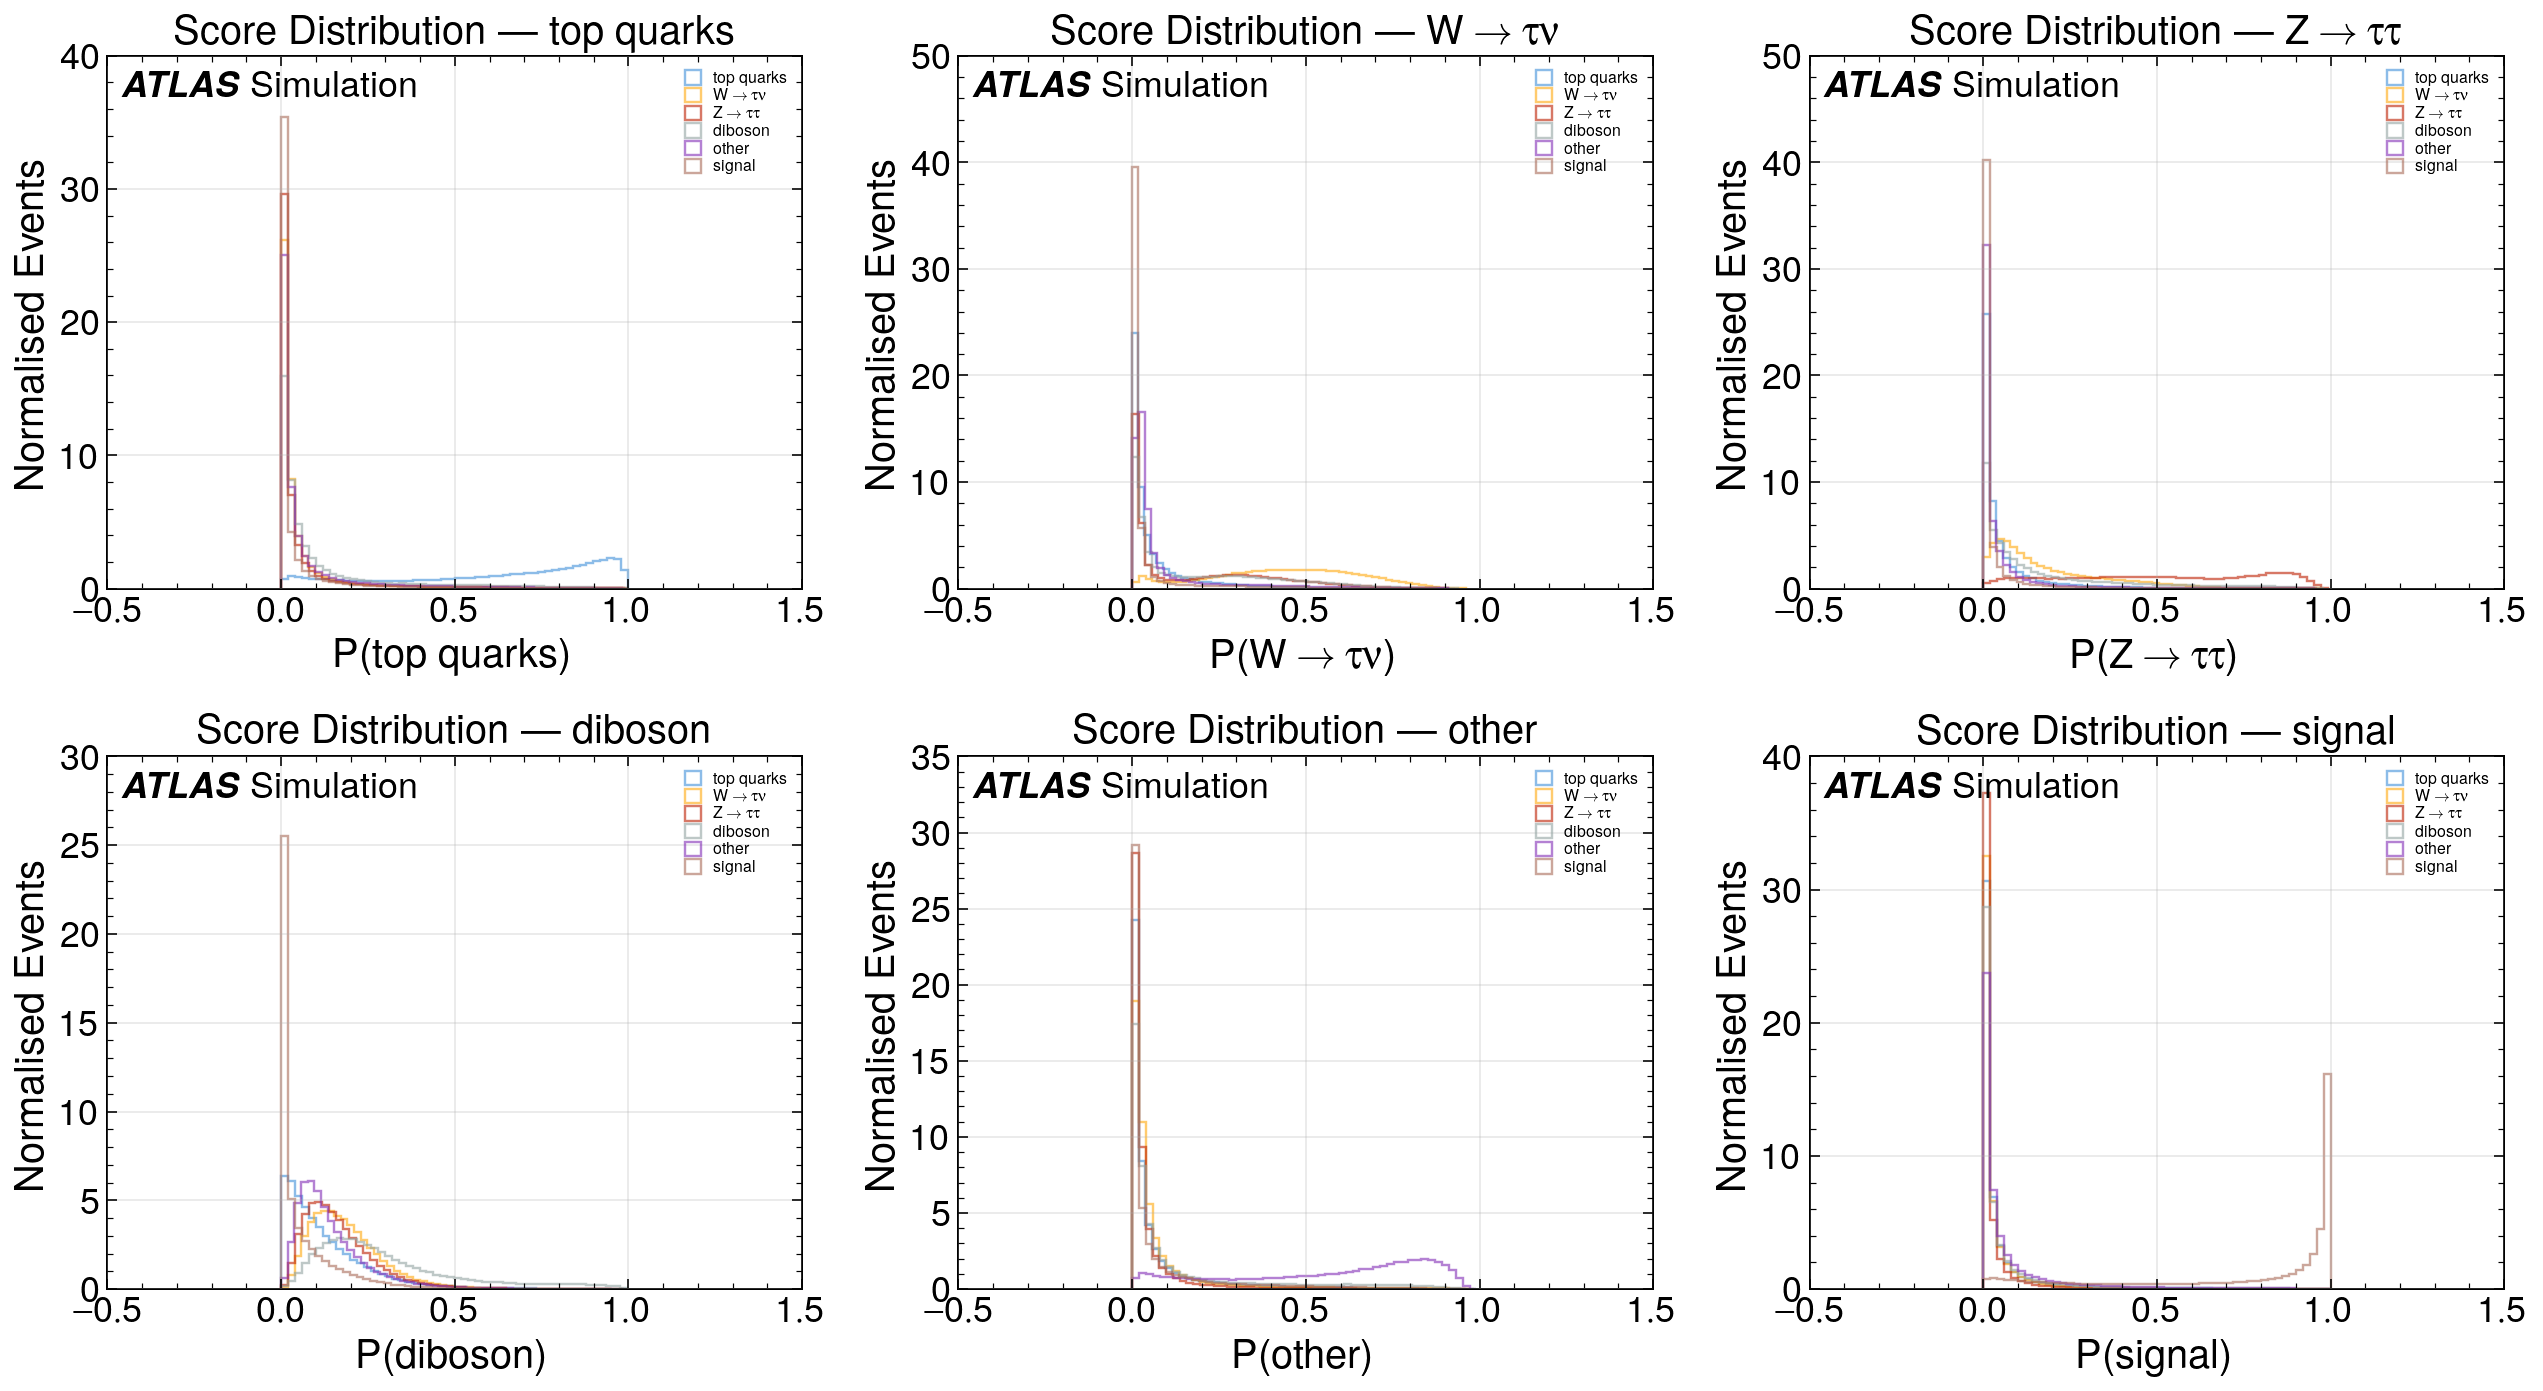

In [19]:
from src.models.evaluation import plot_score_distributions

fig = plot_score_distributions(y_true, y_proba, class_labels=class_labels, bins=50)
sd_path = plots_dir / "score_distributions.png"
save_figure(fig, sd_path)
mlflow.log_artifact(str(sd_path))
fig.show()

## Serialization

Closing the MLflow run. All metrics and artifacts have been logged to the resumed training run.

In [20]:
mlflow.end_run()
print(f"MLflow run {run_id} closed.")

MLflow run c04c0d80bbe6472ba5be3b83e9281179 closed.
